# Used Car Price Prediction — EDA & Preprocessing

This notebook is organised to follow the grading rubric exactly:

- **Section A — Dataset & EDA** (A1 Audit, A2 Visualisations, A3 Insight commentary)
- **Section B — Preprocessing & Feature Engineering** (B1 Cleaning, B2 Encoding/Scaling/Splitting, B3 Feature engineering)

> **Note on pipeline order:** feature engineering (B3) is coded immediately after cleaning (B1) because the
> engineered columns need to exist *before* we select the final feature set and split the data (B2). The
> section **headings** still follow the rubric's B1 → B2 → B3 numbering for easy grading; only the physical
> code order is Clean → Engineer → Split, which is the correct order for a leak-free pipeline.


# Section A — Dataset & EDA

## A1. Dataset Loading & Audit

We load the raw dataset and report its shape, column data types, missing-value counts, and a first look at
the target variable (`AskPrice`) before any cleaning takes place.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the raw dataset
RAW_PATH = "../data/used_car_dataset.csv"

df = pd.read_csv(RAW_PATH)
df.head()

,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice
0,Honda,City,2001,23,"98,000 km",Manual,second,Petrol,Nov-24,"Honda City v teck in mint condition, valid gen...","₹ 1,95,000"
1,Toyota,Innova,2009,15,190000.0 km,Manual,second,Diesel,Jul-24,"Toyota Innova 2.5 G (Diesel) 7 Seater, 2009, D...","₹ 3,75,000"
2,Volkswagen,VentoTest,2010,14,"77,246 km",Manual,first,Diesel,Nov-24,"Volkswagen Vento 2010-2013 Diesel Breeze, 2010...","₹ 1,84,999"
3,Maruti Suzuki,Swift,2017,7,"83,500 km",Manual,second,Diesel,Nov-24,Maruti Suzuki Swift 2017 Diesel Good Condition,"₹ 5,65,000"
4,Maruti Suzuki,Baleno,2019,5,"45,000 km",Automatic,first,Petrol,Nov-24,"Maruti Suzuki Baleno Alpha CVT, 2019, Petrol","₹ 6,85,000"


In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 9582
Number of columns: 11


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9582 entries, 0 to 9581
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Brand         9582 non-null   str  
 1   model         9582 non-null   str  
 2   Year          9582 non-null   int64
 3   Age           9582 non-null   int64
 4   kmDriven      9535 non-null   str  
 5   Transmission  9582 non-null   str  
 6   Owner         9582 non-null   str  
 7   FuelType      9582 non-null   str  
 8   PostedDate    9582 non-null   str  
 9   AdditionInfo  9582 non-null   str  
 10  AskPrice      9582 non-null   str  
dtypes: int64(2), str(9)
memory usage: 823.6 KB


**Missing values (raw columns).** Note that `kmDriven` and `AskPrice` are stored as *text* in the raw
file (they contain commas, the `₹` symbol, and the unit `km`), so a `.isnull()` check at this stage only
catches genuinely empty cells — it will not catch malformed numeric entries. We check again after converting
these columns to numeric type below.

In [5]:
missing_raw = df.isnull().sum()
print("Missing values per column (raw, before type conversion):")
print(missing_raw)
print("\nTotal missing values:", missing_raw.sum())

Missing values per column (raw, before type conversion):
Brand            0
model            0
Year             0
Age              0
kmDriven        47
Transmission     0
Owner            0
FuelType         0
PostedDate       0
AdditionInfo     0
AskPrice         0
dtype: int64

Total missing values: 47


### Data type conversion

`kmDriven` and `AskPrice` are converted from text to numeric so they can be audited and later used for
modelling. Any entry that cannot be parsed becomes `NaN` (`errors="coerce"`), which lets us catch hidden
data-quality issues that a raw `.isnull()` count would miss.

In [6]:
# Convert kmDriven to numeric
df["kmDriven"] = (
    df["kmDriven"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace(" km", "", regex=False)
    .str.strip()
)
df["kmDriven"] = pd.to_numeric(df["kmDriven"], errors="coerce")

# Convert AskPrice to numeric
df["AskPrice"] = (
    df["AskPrice"]
    .astype(str)
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)
df["AskPrice"] = pd.to_numeric(df["AskPrice"], errors="coerce")

df[["kmDriven", "AskPrice"]].head()

,kmDriven,AskPrice
0,98000.0,195000
1,190000.0,375000
2,77246.0,184999
3,83500.0,565000
4,45000.0,685000


In [7]:
missing_after_conversion = df.isnull().sum()
print("Missing values per column (after numeric conversion):")
print(missing_after_conversion)
print("\nTotal missing values:", missing_after_conversion.sum())

Missing values per column (after numeric conversion):
Brand            0
model            0
Year             0
Age              0
kmDriven        47
Transmission     0
Owner            0
FuelType         0
PostedDate       0
AdditionInfo     0
AskPrice         0
dtype: int64

Total missing values: 47


**Target variable audit.** `AskPrice` (the regression target) is a continuous numeric variable, so we
audit its central tendency and spread here rather than a class distribution. Its full visual distribution is
produced later in A2.

In [8]:
print(df["AskPrice"].describe())
print("\nTarget dtype:", df["AskPrice"].dtype)

count    9.582000e+03
mean     1.063609e+06
std      1.658495e+06
min      1.500000e+04
25%      3.610000e+05
50%      5.990000e+05
75%      1.125000e+06
max      4.250000e+07
Name: AskPrice, dtype: float64

Target dtype: int64


**Duplicate rows (audit only).** We count exact duplicate rows here; they are removed later in
Section B1 as part of the cleaning strategy.

In [9]:
print("Number of exact duplicate rows:", df.duplicated().sum())

Number of exact duplicate rows: 731


**Columns out of scope for modelling.** `AdditionInfo` is free-text listing notes and `PostedDate` is a
listing date — neither is a structured predictive feature, so they are excluded from the EDA/feature set
below and are not modelled further.

**Audit summary:** the dataset has the shape, dtypes and missing-value profile reported above; the only
column with missing values after numeric conversion is `kmDriven`, all categorical columns are fully
populated, and the target `AskPrice` is a right-skewed continuous variable (see distribution below).

## A2. Exploratory Data Visualisations
### (with A3 Insight Commentary directly under each plot)

Every plot below is followed by a short written observation describing what it reveals about the data.

### Numerical feature distributions

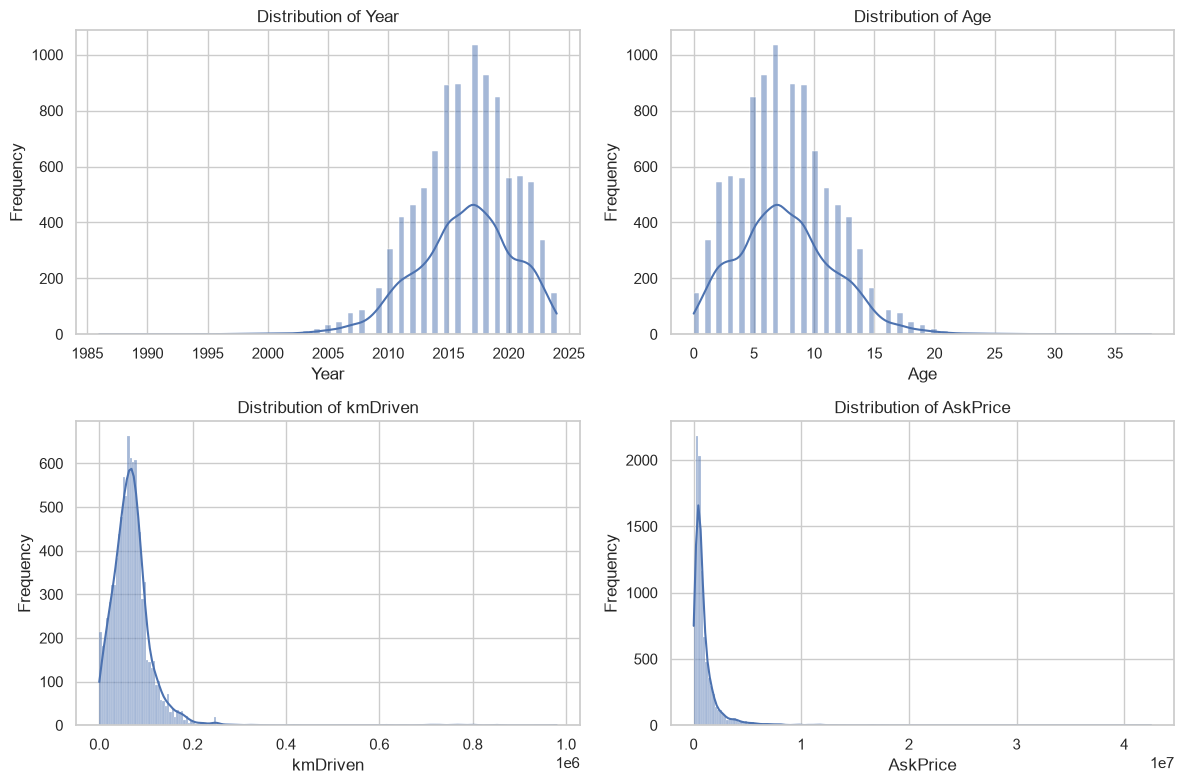

In [10]:
numerical_cols = ["Year", "Age", "kmDriven", "AskPrice"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), numerical_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

**Observation — Year.** Most vehicles in the dataset are from relatively recent model years, with fewer observations for older vehicles.

**Observation — Age.** The distribution is concentrated around younger and moderately aged vehicles, with fewer older vehicles — the mirror image of the `Year` plot, as expected.

**Observation — kmDriven.** The mileage distribution is right-skewed: most vehicles have moderate mileage, with a smaller number of vehicles showing substantially higher mileage.

**Observation — AskPrice.** The asking-price distribution is strongly right-skewed, with most vehicles concentrated at lower prices and a long tail of high-priced vehicles.

### Categorical feature distributions

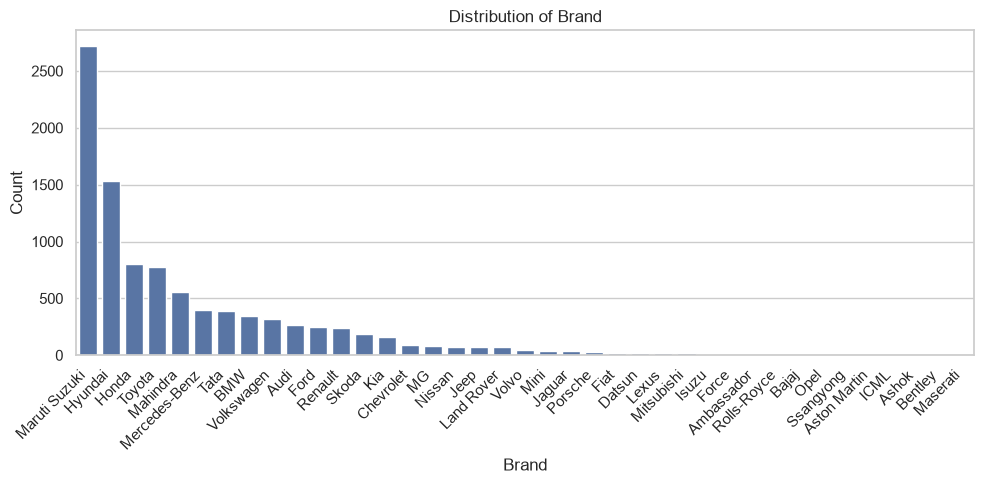

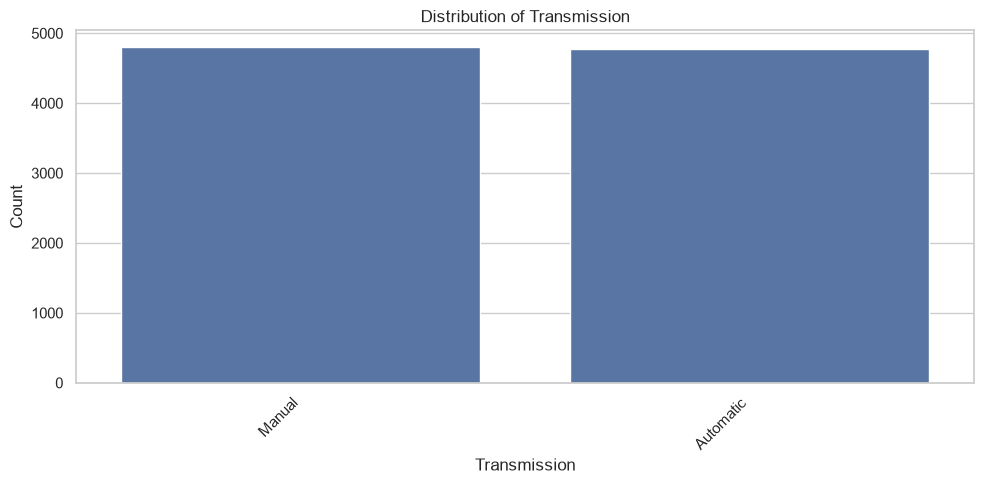

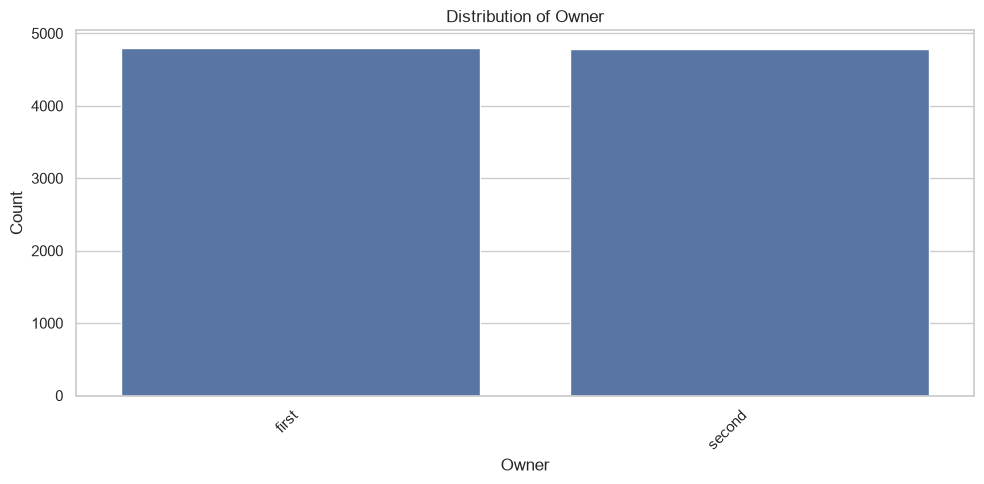

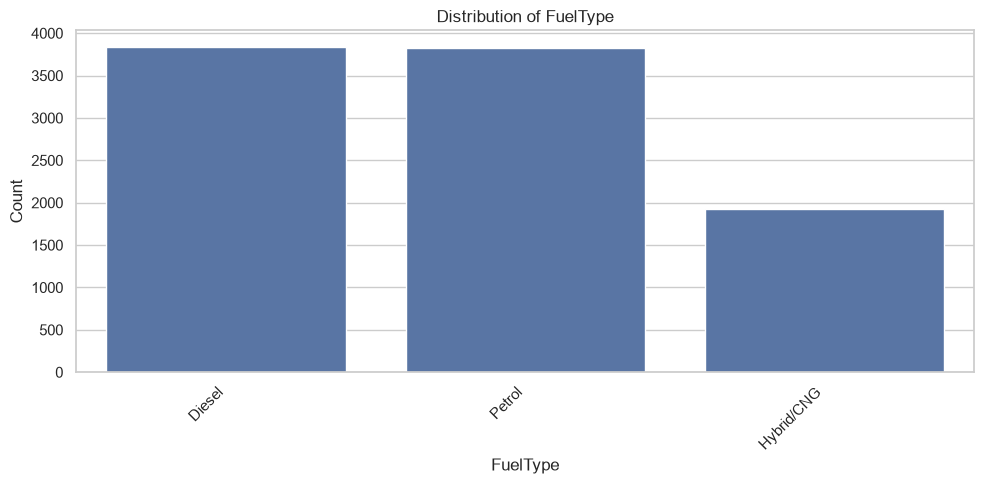

In [11]:
categorical_features = ["Brand", "Transmission", "Owner", "FuelType"]

for col in categorical_features:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

**Observation — Brand.** The dataset contains vehicles from many brands, but a small number of brands dominate the counts — an uneven distribution to keep in mind when one-hot encoding.

**Observation — Transmission.** One transmission type is far more common than the other, so the dataset is imbalanced on this feature.

**Observation — Owner.** Ownership categories are unevenly distributed, with first/second-owner cars far more common than later ones. This may carry useful pricing signal.

**Observation — Fuel Type.** Petrol and diesel vehicles dominate the dataset, with other fuel types much rarer.

`model` has far too many unique values (hundreds of car models) for a readable count plot of every
category, so we instead plot only the 15 most frequent models to still satisfy a per-feature distribution
check without producing an unreadable chart.

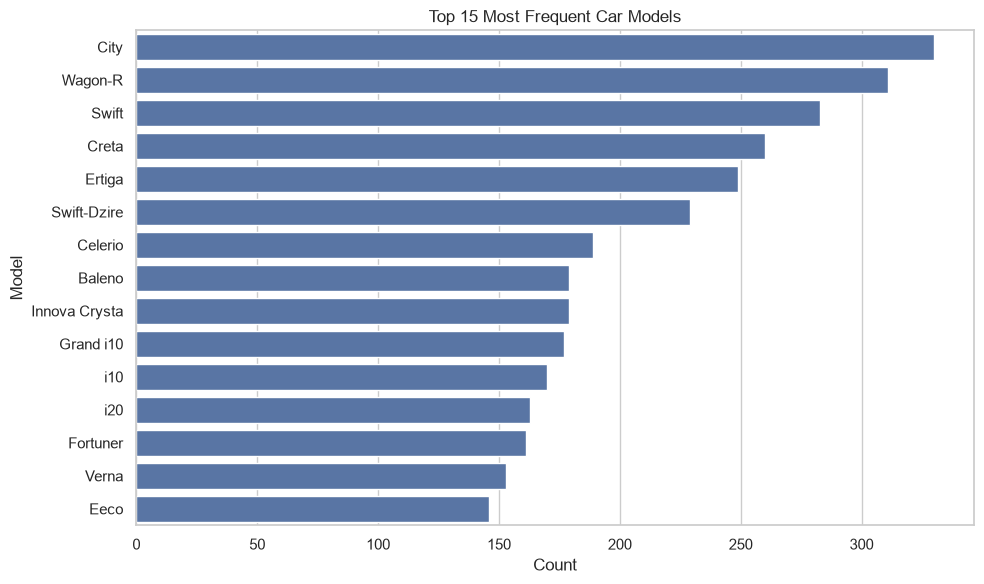

In [12]:
top_models = df["model"].value_counts().head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_models.values, y=top_models.index, orient="h")
plt.title("Top 15 Most Frequent Car Models")
plt.xlabel("Count")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

**Observation — Model (top 15).** A handful of models account for a disproportionate share of listings, confirming that `model` is a high-cardinality feature that will need one-hot encoding with care (large number of resulting columns).

### Numerical feature boxplots (visual outlier check)

Boxplots let us visually flag potential outliers *before* deciding how to treat them in Section B1.

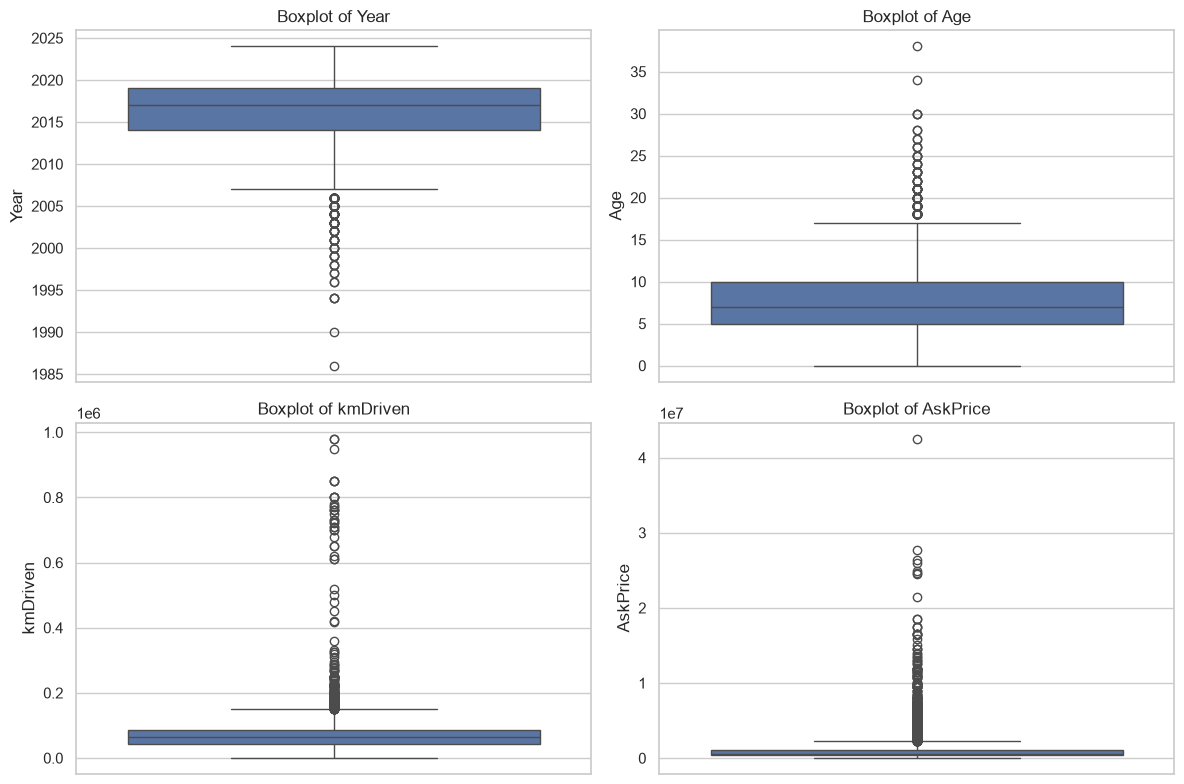

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), numerical_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(f"Boxplot of {col}")
    ax.set_ylabel(col)
plt.tight_layout()
plt.show()

**Observation — Boxplots.** `kmDriven` and `AskPrice` both show a number of points above the upper
whisker, consistent with their right-skewed histograms above. `Year`/`Age` show a smaller number of outliers
at the "very old vehicle" end. None of the extreme values look like impossible data-entry errors (e.g. no
negative mileage or negative price), so in Section B1 we treat them with **capping** rather than deleting the
rows, to avoid discarding real (if unusual) vehicles.

### Correlation heatmap

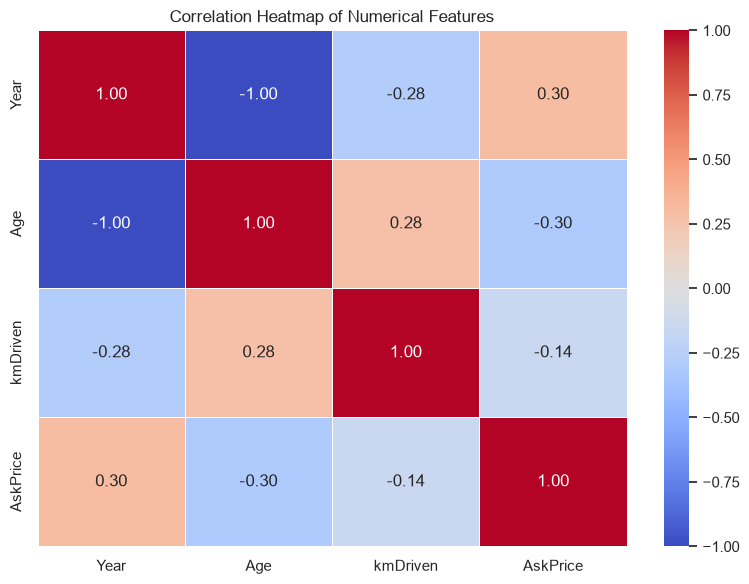

In [14]:
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

**Observation.** `Year` and `Age` are perfectly (negatively) correlated (r = -1.00) — they encode the
same information. `Year` correlates positively with `AskPrice` (~0.31) and `Age` negatively (~-0.31), while
`kmDriven` has a weaker negative correlation with `AskPrice` (~-0.21). Because `Year`/`Age` are redundant, we
drop the original `Age` column later in B3 and keep a single engineered age feature instead, to avoid feeding
duplicated information into the model.

### Target variable distribution (focused view)

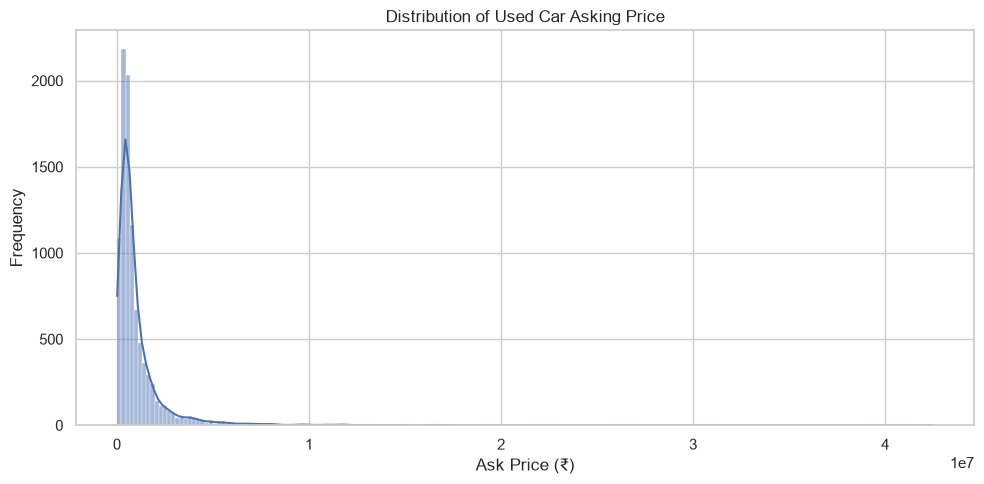

In [15]:
plt.figure(figsize=(10, 5))
sns.histplot(df["AskPrice"], kde=True)
plt.title("Distribution of Used Car Asking Price")
plt.xlabel("Ask Price (₹)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

**Observation.** The asking-price distribution is highly right-skewed: most vehicles are priced relatively low, with a smaller number of much higher-priced vehicles pulling the mean above the median.

### Feature vs. target relationships (scatter plots)

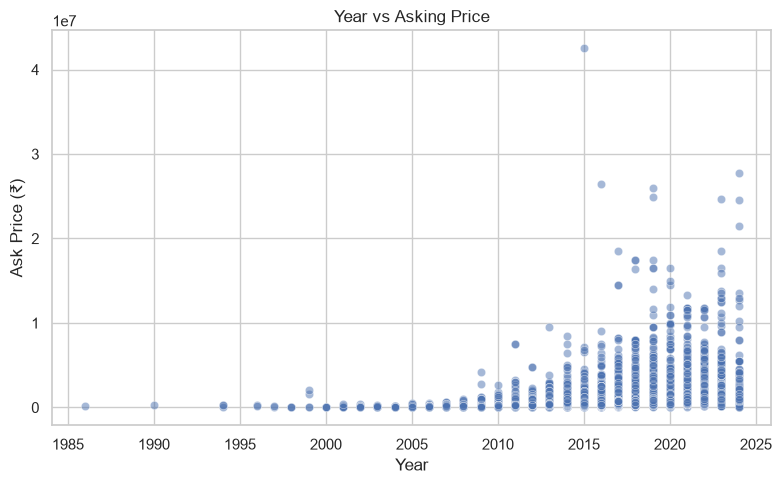

In [16]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Year", y="AskPrice", alpha=0.5)
plt.title("Year vs Asking Price")
plt.xlabel("Year")
plt.ylabel("Ask Price (₹)")
plt.tight_layout()
plt.show()

**Observation — Year vs Asking Price.** Newer vehicles tend to have higher asking prices, although there is considerable spread within any given model year.

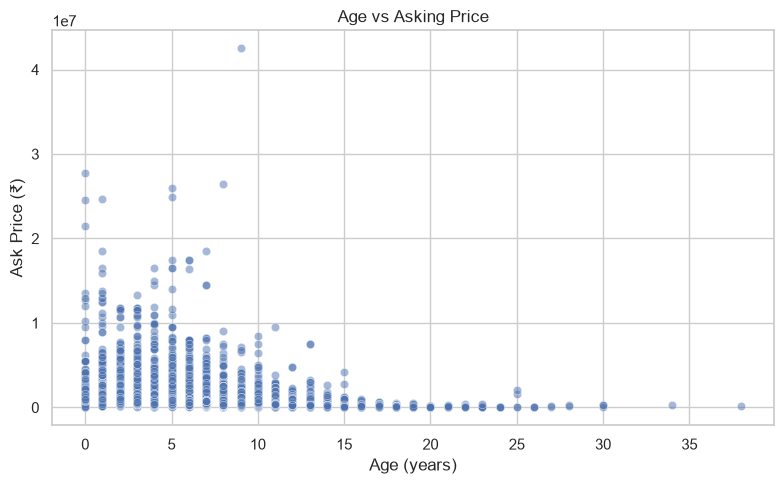

In [17]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Age", y="AskPrice", alpha=0.5)
plt.title("Age vs Asking Price")
plt.xlabel("Age (years)")
plt.ylabel("Ask Price (₹)")
plt.tight_layout()
plt.show()

**Observation — Age vs Asking Price.** Asking price generally decreases as vehicle age increases, consistent with typical depreciation, though other factors clearly also drive price.

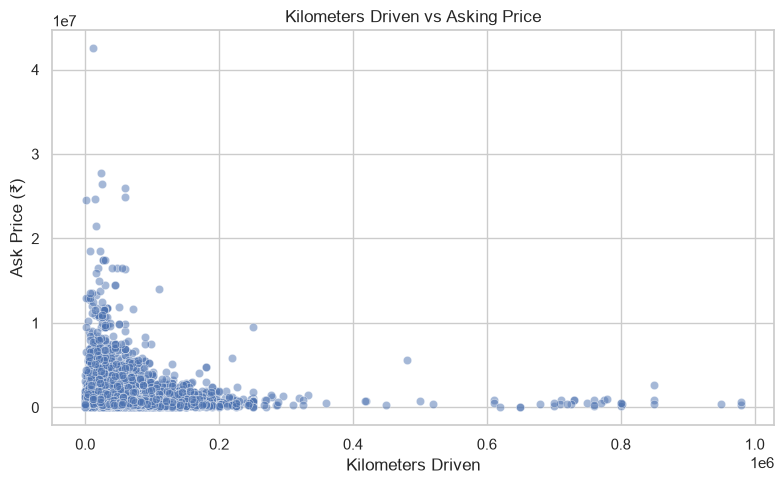

In [18]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="kmDriven", y="AskPrice", alpha=0.5)
plt.title("Kilometers Driven vs Asking Price")
plt.xlabel("Kilometers Driven")
plt.ylabel("Ask Price (₹)")
plt.tight_layout()
plt.show()

**Observation — kmDriven vs Asking Price.** There is a weak negative relationship: higher-mileage vehicles tend to be priced lower, but the relationship is noisy, suggesting mileage alone is not a strong predictor.

# Section B — Preprocessing & Feature Engineering

## B1. Data Cleaning

Strategy, justified:

- **Missing numeric values (`kmDriven`)** → filled with the **median**, because mileage can contain extreme
  values and the median is robust to outliers (mean would be pulled by the high-mileage tail we saw above).
- **Missing categorical values** → filled with the **mode** (most frequent category). The code below checks
  every categorical column defensively and only fills where missing values actually exist, so the notebook
  stays correct even if a different data pull has missing categorical entries.
- **Duplicates** → exact duplicate rows are dropped, since repeated rows would let the same observation
  influence the model multiple times.
- **Outliers** → detected with the IQR rule and treated with **capping** (winsorising) rather than deletion,
  because the boxplots in A2 showed these are plausible real vehicles, not data-entry errors, and capping
  reduces their influence without throwing away data.

In [19]:
# --- Missing numeric values: kmDriven ---
median_km = df["kmDriven"].median()
df["kmDriven"] = df["kmDriven"].fillna(median_km)

print("Median kmDriven used for imputation:", median_km)
print("Missing kmDriven after imputation:", df["kmDriven"].isnull().sum())

Median kmDriven used for imputation: 65000.0
Missing kmDriven after imputation: 0


In [20]:
# --- Missing categorical values: mode imputation (defensive, applies to any column that has NaNs) ---
categorical_cols_all = ["Brand", "model", "Transmission", "Owner", "FuelType"]

for col in categorical_cols_all:
    n_missing = df[col].isnull().sum()
    if n_missing > 0:
        mode_value = df[col].mode()[0]
        df[col] = df[col].fillna(mode_value)
        print(f"{col}: filled {n_missing} missing values with mode '{mode_value}'")
    else:
        print(f"{col}: no missing values found, nothing to impute")

Brand: no missing values found, nothing to impute
model: no missing values found, nothing to impute
Transmission: no missing values found, nothing to impute
Owner: no missing values found, nothing to impute
FuelType: no missing values found, nothing to impute


In [21]:
# --- Duplicate rows ---
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows found:", duplicate_count)

df = df.drop_duplicates().reset_index(drop=True)
print("Dataset shape after removing duplicates:", df.shape)

Number of duplicate rows found: 731
Dataset shape after removing duplicates: (8851, 11)


In [22]:
# --- Outlier detection (IQR rule) ---
outlier_cols = ["Year", "Age", "kmDriven"]  # AskPrice (target) is excluded — see note below

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    print(f"{col}: Q1={Q1:.1f}, Q3={Q3:.1f}, IQR={IQR:.1f}, "
          f"bounds=[{lower_bound:.1f}, {upper_bound:.1f}], potential outliers={n_outliers}")

Year: Q1=2014.0, Q3=2019.0, IQR=5.0, bounds=[2006.5, 2026.5], potential outliers=133
Age: Q1=5.0, Q3=10.0, IQR=5.0, bounds=[-2.5, 17.5], potential outliers=133
kmDriven: Q1=43327.0, Q3=86000.0, IQR=42673.0, bounds=[-20682.5, 150009.5], potential outliers=338


`AskPrice` (the target) is intentionally **not** capped: it represents the actual regression target, and
legitimate high-priced vehicles should remain so the model can learn to predict them. Capping predictor
columns is a preprocessing choice about *inputs*; capping the target would artificially distort what we are
trying to predict.

In [23]:
# --- Outlier treatment: IQR-based capping on predictor columns only ---
cols_to_cap = ["Year", "Age", "kmDriven"]

for col in cols_to_cap:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

print("IQR-based capping applied to:", cols_to_cap)

IQR-based capping applied to: ['Year', 'Age', 'kmDriven']


In [34]:
df = df.drop_duplicates().reset_index(drop=True)

In [35]:
print("Remaining duplicate rows:", df.duplicated().sum())

Remaining duplicate rows: 0


In [24]:
# --- Final verification ---
print("Remaining missing values:\n", df.isnull().sum())
print("\nRemaining duplicate rows:", df.duplicated().sum())
df[["Year", "Age", "kmDriven", "AskPrice"]].describe()

Remaining missing values:
 Brand           0
model           0
Year            0
Age             0
kmDriven        0
Transmission    0
Owner           0
FuelType        0
PostedDate      0
AdditionInfo    0
AskPrice        0
dtype: int64

Remaining duplicate rows: 1


,Year,Age,kmDriven,AskPrice
count,8851.000000,8851.000000,8851.000000,8.851000e+03
mean,2016.424076,7.575924,67411.801152,1.038644e+06
std,3.981319,3.981319,34929.990325,1.650188e+06
min,2006.500000,0.000000,0.000000,1.500000e+04
25%,2014.000000,5.000000,43327.000000,3.500000e+05
50%,2017.000000,7.000000,65000.000000,5.900000e+05
75%,2019.000000,10.000000,86000.000000,1.075000e+06
max,2024.000000,17.500000,150009.500000,4.250000e+07


## B3. Feature Engineering

*(Coded here, right after cleaning, so the new columns are available for the train/test split in B2 below —
see the pipeline-order note at the top of the notebook.)*

The heatmap in A2 showed `Year` and `Age` are perfectly correlated (r = -1.00): they carry identical
information, so keeping both would add redundant, collinear input to the model. We therefore:

1. Engineer `car_age = 2026 - Year` (current-year reference), which is interpretable and directly usable.
2. **Drop the original `Age` column**, since it duplicates `car_age` and would otherwise let the same signal
   enter the model twice.
3. Engineer a second, genuinely new feature: **`km_per_year` = `kmDriven / (car_age + 1)`** (the `+1` avoids
   division by zero for brand-new cars). This captures *usage intensity* — a 2-year-old car with 60,000 km
   has been driven much harder than a 10-year-old car with the same mileage, and that wear-and-tear signal is
   lost if `kmDriven` and `car_age` are only ever considered separately. Both engineered features are derived
   purely from `Year`/`kmDriven`, so this is safe, leakage-free row-wise engineering.

In [25]:
# 1. Car age (replaces the redundant original 'Age' column)
CURRENT_YEAR = 2026
df["car_age"] = CURRENT_YEAR - df["Year"]

# 2. Drop the redundant original Age column (perfectly correlated with Year/car_age)
df = df.drop(columns=["Age"])

# 3. Usage-intensity feature: km driven per year of age
df["km_per_year"] = df["kmDriven"] / (df["car_age"] + 1)

df[["Year", "car_age", "kmDriven", "km_per_year"]].head()

,Year,car_age,kmDriven,km_per_year
0,2006.5,19.5,98000.0,4780.487805
1,2009.0,17.0,150009.5,8333.861111
2,2010.0,16.0,77246.0,4543.882353
3,2017.0,9.0,83500.0,8350.000000
4,2019.0,7.0,45000.0,5625.000000


**Why these help.** `car_age` gives the model a single, non-redundant measure of vehicle age (instead of
two collinear columns). `km_per_year` gives the model a measure of *how hard* a car has been used, which
`kmDriven` and `car_age` alone cannot express jointly — two cars with identical mileage but very different
ages likely have different wear, and this feature should help the model separate them.

## B2. Encoding, Scaling & Splitting

Final feature set (categorical + numeric, including the engineered features from B3), stratified train/test
split on binned price so both sets have a similar price distribution, then one-hot encoding for categoricals
and standard scaling for numeric columns — **fitted on the training set only** to avoid leakage from the test
set into preprocessing statistics.

In [26]:
features = [
    "Brand",
    "model",
    "kmDriven",
    "Transmission",
    "Owner",
    "FuelType",
    "car_age",
    "km_per_year",
]

X = df[features].copy()
y = df["AskPrice"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (8851, 8)
y shape: (8851,)


### Train-test split

`AskPrice` is continuous, so we cannot stratify on the raw target directly. Instead we temporarily bin the
target into quantiles and stratify on those bins, so both the train and test sets have a similar price
distribution. The original continuous `AskPrice` values are used for modelling — only the split itself uses
the binned version.

In [27]:
from sklearn.model_selection import train_test_split

price_bins = pd.qcut(y, q=5, labels=False, duplicates="drop")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=price_bins,
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (7080, 8)
X_test: (1771, 8)
y_train: (7080,)
y_test: (1771,)


### Encoding & scaling

Categorical columns are one-hot encoded; numeric columns are standardised with `StandardScaler`. The
`ColumnTransformer` is **fit only on `X_train`** and then used to *transform* both `X_train` and `X_test`, so
no information from the test set leaks into the scaling statistics or encoding categories.

In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_features = ["Brand", "model", "Transmission", "Owner", "FuelType"]
numerical_features = ["kmDriven", "car_age", "km_per_year"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

In [29]:
X_train_processed = preprocessor.fit_transform(X_train)   # fit ONLY on training data
X_test_processed = preprocessor.transform(X_test)             # test data only transformed, never fit

print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)

Processed X_train shape: (7080, 433)
Processed X_test shape: (1771, 433)


In [30]:
X_train_final = X_train_processed
X_test_final = X_test_processed

print("Final X_train shape:", X_train_final.shape)
print("Final X_test shape:", X_test_final.shape)

Final X_train shape: (7080, 433)
Final X_test shape: (1771, 433)


### Saving outputs

The fitted preprocessor is saved for reuse in modelling. The cleaned dataset is saved to a **new** file
(`used_car_dataset_cleaned.csv`) rather than overwritten back onto the raw input file, so the raw data stays
intact and the notebook remains reproducible from scratch on every re-run.

In [31]:
import os
import joblib

os.makedirs("../models", exist_ok=True)
joblib.dump(preprocessor, "../models/preprocessor.pkl")
print("Preprocessor saved successfully!")

Preprocessor saved successfully!


In [32]:
CLEANED_PATH = "../data/used_car_dataset_cleaned.csv"
df.to_csv(CLEANED_PATH, index=False)
print("Cleaned dataset saved to:", CLEANED_PATH)
print("Final shape:", df.shape)

Cleaned dataset saved to: ../data/used_car_dataset_cleaned.csv
Final shape: (8851, 12)
